"""
AR + KNN Unified Recommender System (Olist Dataset)
=====================================================
Flow:
  1. Mount Drive & Load Data
  2. ETL  – Chuẩn bị dữ liệu cho tất cả mô hình
  3. Apriori  – Luật kết hợp theo danh mục
  4. KNN Content-Based  – Tương đồng theo thuộc tính sản phẩm
  5. KNN Item-Based Collaborative  – Tương đồng theo hành vi mua của khách hàng (cosine trên ma trận customer × category)
  6. Hybrid 3 tầng  – Apriori → KNN Content → KNN Collab
  7. Đánh giá riêng lẻ từng chiến lược & So sánh tổng hợp
"""

# 0. SETUP – Mount Drive & Cài thư viện

In [1]:
import os

data_path = '../data'

if os.path.exists(data_path):
    print(f"Directory found: {os.listdir(data_path)}")
else:
    print("Directory does not exist.")

Directory found: ['olist_products_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_customers_dataset.csv', 'olist_sellers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_order_reviews_dataset.csv', 'product_category_name_translation.csv', 'olist_order_payments_dataset.csv']


In [2]:
# !uv pip install efficient-apriori pandas numpy scikit-learn matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from efficient_apriori import apriori
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split

# ============================================================
# 1. ETL – Trích xuất và Tiền xử lý
# ============================================================
# Tạo ra TẤT CẢ các cấu trúc dữ liệu cần thiết cho 3 mô hình:
#   - transactions          → Apriori
#   - product_features      → KNN Content-Based (có physical dims)
#   - customer_cat_matrix   → KNN Item-Based Collaborative

In [3]:
def etl_olist_data(data_path):
    print("=" * 60)
    print("ETL: Đang tải dữ liệu...")
    print("=" * 60)

    # --- Load CSV files ---
    orders       = pd.read_csv(os.path.join(data_path, 'olist_orders_dataset.csv'))
    order_items  = pd.read_csv(os.path.join(data_path, 'olist_order_items_dataset.csv'))
    products     = pd.read_csv(os.path.join(data_path, 'olist_products_dataset.csv'))
    translation  = pd.read_csv(os.path.join(data_path, 'product_category_name_translation.csv'))
    customers    = pd.read_csv(os.path.join(data_path, 'olist_customers_dataset.csv'))

    # --- Chỉ lấy đơn hàng đã giao thành công ---
    print("\n[ETL] Lọc đơn hàng đã giao thành công...")
    delivered = orders[orders['order_status'] == 'delivered'][['order_id', 'customer_id']]

    # --- Merge bảng chính ---
    print("[ETL] Merge các bảng dữ liệu...")
    df = pd.merge(order_items, delivered, on='order_id')
    df = pd.merge(df, customers[['customer_id', 'customer_unique_id']], on='customer_id')
    df = pd.merge(df, products[['product_id', 'product_category_name']], on='product_id')
    df = pd.merge(df, translation, on='product_category_name', how='left')
    df['product_category_name_english'] = df['product_category_name_english'].fillna('others')

    print(f" Dữ liệu sau merge: {df.shape}, sample:\n{df.head()}")
    
    # ── CHUẨN BỊ DỮ LIỆU CHO APRIORI ──────────────────────────
    # Transactions theo danh mục (mỗi đơn hàng = 1 tập categories)
    print("[ETL] Tạo Transactions cho Apriori...")
    transactions = (
        df.groupby('order_id')['product_category_name_english']
          .apply(lambda x: list(set(x)))
          .values.tolist()
    )
    transactions = [t for t in transactions if len(t) > 1]
    print(f" transactions (đơn hàng có ≥2 categories): {transactions[:5]} ...")

    # ── CHUẨN BỊ DỮ LIỆU CHO KNN CONTENT-BASED ─────────────────
    # product_features: category + physical dimensions (weight, size)
    print("[ETL] Tạo Product Features cho KNN Content-Based...")
    product_features = products.copy()
    product_features = pd.merge(product_features, translation,
                                on='product_category_name', how='left')
    product_features['product_category_name_english'] = (
        product_features['product_category_name_english'].fillna('others')
    )
    keep_cols = ['product_id', 'product_category_name_english',
                 'product_weight_g', 'product_length_cm',
                 'product_height_cm', 'product_width_cm']
    product_features = product_features[keep_cols].fillna(0)
    print(f" product_features sample:\n{product_features.head()}")

    # ── CHUẨN BỊ DỮ LIỆU CHO KNN ITEM-BASED COLLABORATIVE ──────
    # Ma trận nhị phân: khách hàng (hàng) × danh mục (cột)
    print("[ETL] Tạo Ma trận Customer × Category cho KNN Collaborative...")
    customer_cat_matrix = pd.crosstab(
        df['customer_unique_id'],
        df['product_category_name_english']
    )
    customer_cat_matrix = (customer_cat_matrix > 0).astype(int)
    print(f" customer_cat_matrix sample:\n{customer_cat_matrix.head()}")
    # ── TỔNG KẾT ETL ─────────────────────────────────────────────
    print(f"\n--- ETL SUCCESS ---")
    print(f"  Số giao dịch (Apriori):                    {len(transactions)}")
    print(f"  Số sản phẩm  (KNN Content):                {len(product_features)}")
    print(f"  Kích thước ma trận Customer×Category (KNN Collab): {customer_cat_matrix.shape}")

    return transactions, product_features, customer_cat_matrix


transactions, product_features, customer_cat_matrix = etl_olist_data(data_path)

ETL: Đang tải dữ liệu...

[ETL] Lọc đơn hàng đã giao thành công...
[ETL] Merge các bảng dữ liệu...
 Dữ liệu sau merge: (110197, 11), sample:
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  \
0  2017-09-19 09:45:35   58.90          13.29 

# ============================================================
# 2. APRIORI – Luật kết hợp danh mục
# ============================================================

In [4]:
def train_apriori_model(transactions):
    """
    Sinh luật kết hợp theo danh mục.
    Trả về dict: { 'category_A': [{'category': 'cat_B', 'score': lift, 'method': ...}, ...] }
    """
    itemsets, rules = apriori(
        transactions,
        # min_support=0.0005,
        min_support=0.0002,
        min_confidence=0.1,
        max_length=3
    )

    apriori_dict = {}
    for rule in rules:
        lhs_items = list(rule.lhs)
        rhs_items = list(rule.rhs)

        if not lhs_items or not rhs_items:
            continue

        for lhs_cat in lhs_items:
            for rhs_cat in rhs_items:
                apriori_dict.setdefault(lhs_cat, []).append({
                    'category': rhs_cat,
                    'score': round(rule.lift, 4),
                    'method': 'Apriori'
                })

    for cat in apriori_dict:
        apriori_dict[cat] = sorted(apriori_dict[cat],
                                   key=lambda x: x['score'], reverse=True)

    print(f"\n--- APRIORI SUCCESS ---")
    print(f"  Số luật kết hợp được sinh ra: {len(rules)}")
    print(f"  Apriori Rules:\n{apriori_dict}")
    return apriori_dict


apriori_rules_lookup = train_apriori_model(transactions)

# Demo tra cứu
sample_cat = list(apriori_rules_lookup.keys())[0] if apriori_rules_lookup else None
if sample_cat:
    print(f"\nDemo – Gợi ý Apriori cho danh mục '{sample_cat}':")
    for r in apriori_rules_lookup[sample_cat][:3]:
        print(f"  → {r['category']}  (lift={r['score']})")


--- APRIORI SUCCESS ---
  Số luật kết hợp được sinh ra: 209
  Apriori Rules:
{'air_conditioning': [{'category': 'computers_accessories', 'score': 7.6471, 'method': 'Apriori'}, {'category': 'sports_leisure', 'score': 5.4167, 'method': 'Apriori'}], 'art': [{'category': 'stationery', 'score': 3.9394, 'method': 'Apriori'}, {'category': 'furniture_decor', 'score': 3.1863, 'method': 'Apriori'}], 'arts_and_craftmanship': [{'category': 'toys', 'score': 7.6471, 'method': 'Apriori'}, {'category': 'garden_tools', 'score': 5.493, 'method': 'Apriori'}], 'watches_gifts': [{'category': 'audio', 'score': 19.5, 'method': 'Apriori'}, {'category': 'furniture_decor', 'score': 1.9118, 'method': 'Apriori'}, {'category': 'sports_leisure', 'score': 1.3542, 'method': 'Apriori'}, {'category': 'housewares', 'score': 0.9606, 'method': 'Apriori'}, {'category': 'furniture_decor', 'score': 0.6691, 'method': 'Apriori'}], 'audio': [{'category': 'watches_gifts', 'score': 19.5, 'method': 'Apriori'}], 'christmas_supplie

# ==================================================================
# 3. KNN CONTENT-BASED – Tương đồng theo thuộc tính vật lý sản phẩm
# ==================================================================
# LÝ DO KHÔNG DÙNG OneHot(category):
   Feature matrix có 72 chiều one-hot (category) vs 4 chiều số (physical dims).
   Nếu giữ category, cosine similarity giữa 2 sản phẩm cùng category ≈ 1.0,
   còn khác category ≈ 0.0 → KNN Content chỉ trả về sản phẩm CÙNG danh mục.
   Khi đánh giá cross-category, kết quả luôn = 0 (không có ý nghĩa).
# GIẢI PHÁP: Chỉ dùng physical dimensions (weight, length, height, width).
   KNN Content sẽ tìm sản phẩm tương đồng về đặc trưng vật lý BẤT KỂ danh mục
   (ví dụ: đồ dùng nhà bếp nhỏ gọn ↔ phụ kiện điện tử nhỏ gọn).
   Ba mô hình khi đó thực sự bổ sung cho nhau:
     • Apriori   → quy luật mua kèm theo danh mục (lịch sử giao dịch)
     • Content   → tương đồng vật lý (kích thước, trọng lượng)
     • Collab    → hành vi mua tương đồng qua ma trận khách hàng

In [5]:
def train_knn_content(product_features):
    """
    Content-Based KNN dựa trên thuộc tính vật lý thuần túy (không dùng category).
    Trả về: (knn_model, feature_matrix, product_features_reset, category_to_products)
    """
    numerical_features = ['product_weight_g', 'product_length_cm',
                           'product_height_cm', 'product_width_cm']

    # Reset index để đảm bảo positional index khớp với feature_matrix row index
    pf = product_features.reset_index(drop=True)

    scaler = StandardScaler()
    feature_matrix = scaler.fit_transform(pf[numerical_features].values)

    knn_content = NearestNeighbors(n_neighbors=30, metric='cosine', algorithm='brute')
    knn_content.fit(feature_matrix)

    # Map: category → [product_ids]
    cat_to_products = (
        pf.groupby('product_category_name_english')['product_id']
          .apply(list).to_dict()
    )

    print("\n--- KNN CONTENT-BASED SUCCESS ---")
    print(f"  Feature matrix shape: {feature_matrix.shape}")
    print(f"  Đặc trưng: {numerical_features}")
    print(f"  (Category đã được tách ra để tránh dominate cosine similarity)")
    print(f"  Ví dụ mapping category → product_ids:\n    {list(cat_to_products.items())[:3]}")
    return knn_content, feature_matrix, pf, cat_to_products


knn_content, feature_matrix, product_features, category_to_products = train_knn_content(product_features)


--- KNN CONTENT-BASED SUCCESS ---
  Feature matrix shape: (32951, 4)
  Đặc trưng: ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
  (Category đã được tách ra để tránh dominate cosine similarity)
  Ví dụ mapping category → product_ids:
    [('agro_industry_and_commerce', ['07f01b6fcacc1b187a71e5074199db2d', '613d093272cb8f74f25a01e430155a6a', '980ecbcc15fe174ec1e5757c4d75b1bf', 'ba1d7e7ee1f055d252a2faa8ea3cea9b', '137ace556a03792cdc43f91ec621426d', 'eb1e85561435be5d1760939dac8c881c', 'b5015f9057f27b5bdefde4ca99368b54', '51d1db0b0ed8fee9994a5bae549a6160', '0b2a1288e8ba64c797e7586c8df75602', '3e3f442db862cb6fe99389a41b7acb84', '423a6644f0aa529e8828ff1f91003690', 'a2f25a7e9c4eea1e3c2949d03c688048', '4796ab0f0b86b1d3aeea60f77a0ad991', '49b6d7e8192cd04ef8f69b1bf00b7eb1', 'cd2f5c10e4e8dbc701f0bb68a09fdfe8', '1db1301d6b2401401a26dd1aabcb809e', '163a503e8aa4c48bfd077f416e4341d4', 'be55ae76be8824525f40695d49a5a7b5', '137f49a66ce117db74acbaf30c047701', 'a0fe1ef

# ============================================================
# 4. KNN ITEM-BASED COLLABORATIVE – Tương đồng danh mục qua hành vi mua
# ============================================================
# Xây dựng vector đặc trưng cho từng DANH MỤC = hàng trong ma trận
# (Danh mục × Khách hàng), rồi tính cosine similarity để tìm các
# danh mục có hành vi mua tương đồng.

In [6]:
def train_knn_collab(customer_cat_matrix, product_features):
    """
    Item-Based Collaborative KNN dựa trên ma trận Customer × Category.
    Chuyển vị thành Category × Customer để tính cosine giữa các danh mục.
    Trả về: (knn_model, cat_customer_matrix, category_names, cat_to_products)
    """
    # Chuyển vị: hàng = Danh mục, cột = Khách hàng
    cat_customer_matrix = customer_cat_matrix.T

    knn_collab = NearestNeighbors(n_neighbors=10, metric='cosine', algorithm='brute')
    knn_collab.fit(cat_customer_matrix.values)

    category_names = cat_customer_matrix.index.tolist()

    # Map: category → [product_ids]  (dùng product_features gọn nhẹ hơn)
    cat_to_products_collab = (
        product_features.groupby('product_category_name_english')['product_id']
                        .apply(list).to_dict()
    )

    print("\n--- KNN ITEM-BASED COLLABORATIVE SUCCESS ---")
    print(f"  Số danh mục trong ma trận: {len(category_names)}")
    print(f"  Số khách hàng trong ma trận: {cat_customer_matrix.shape[1]}")
    print(f"  Ví dụ mapping category → product_ids:\n    {list(cat_to_products_collab.items())[:3]}")
    return knn_collab, cat_customer_matrix, category_names, cat_to_products_collab


knn_collab, cat_customer_matrix, category_names, cat_to_products_collab = train_knn_collab(
    customer_cat_matrix, product_features
)

# Hợp nhất 2 map category → products (lấy union để không bỏ sót)
for cat, ids in cat_to_products_collab.items():
    if cat not in category_to_products:
        category_to_products[cat] = ids


--- KNN ITEM-BASED COLLABORATIVE SUCCESS ---
  Số danh mục trong ma trận: 72
  Số khách hàng trong ma trận: 93358
  Ví dụ mapping category → product_ids:
    [('agro_industry_and_commerce', ['07f01b6fcacc1b187a71e5074199db2d', '613d093272cb8f74f25a01e430155a6a', '980ecbcc15fe174ec1e5757c4d75b1bf', 'ba1d7e7ee1f055d252a2faa8ea3cea9b', '137ace556a03792cdc43f91ec621426d', 'eb1e85561435be5d1760939dac8c881c', 'b5015f9057f27b5bdefde4ca99368b54', '51d1db0b0ed8fee9994a5bae549a6160', '0b2a1288e8ba64c797e7586c8df75602', '3e3f442db862cb6fe99389a41b7acb84', '423a6644f0aa529e8828ff1f91003690', 'a2f25a7e9c4eea1e3c2949d03c688048', '4796ab0f0b86b1d3aeea60f77a0ad991', '49b6d7e8192cd04ef8f69b1bf00b7eb1', 'cd2f5c10e4e8dbc701f0bb68a09fdfe8', '1db1301d6b2401401a26dd1aabcb809e', '163a503e8aa4c48bfd077f416e4341d4', 'be55ae76be8824525f40695d49a5a7b5', '137f49a66ce117db74acbaf30c047701', 'a0fe1efb855f3e786f0650268cd77f44', '24fee4a800146a47846fa0e345b6d6ed', '1f541a93f4fa4b8d15c7d5ed83836484', 'cf4f52b8f3c906f

# ============================================================
# 5. HYBRID RECOMMENDER – 3 tầng: Apriori → KNN Content → KNN Collab
# ============================================================
# Tầng 1 (Apriori):   Ưu tiên các danh mục có luật mua kèm mạnh (lift cao)
# Tầng 2 (Content):   Bù đắp bằng sản phẩm tương đồng về đặc trưng vật lý
# Tầng 3 (Collab):    Bù đắp cuối bằng danh mục có hành vi mua tương đồng
#                     (cosine similarity trên không gian khách hàng)

In [7]:
def get_hybrid_recommendations(product_id, k=10):
    """
    Trả về list tối đa k sản phẩm gợi ý kèm score và method nguồn gốc.
    Tầng 1: Apriori → Tầng 2: KNN Collab → Tầng 3: KNN Content
    """
    final_recs = []
    seen_ids   = {product_id}

    rows = product_features[product_features['product_id'] == product_id]
    if rows.empty:
        return []
    current_cat = rows.iloc[0]['product_category_name_english']

    # ── TẦNG 1: APRIORI ─────────────────────────────────────────
    suggested_cats = apriori_rules_lookup.get(current_cat, [])
    unique_suggested_cats = []
    seen_cat = set()
    for cat_rule in suggested_cats:
        if cat_rule['category'] not in seen_cat:
            unique_suggested_cats.append(cat_rule)
            seen_cat.add(cat_rule['category'])
    suggested_cats = unique_suggested_cats

    apriori_cat_counts = {cat_rule['category']: 0 for cat_rule in suggested_cats}
    max_per_category = 1

    while len(final_recs) < k:
        added = False
        for cat_rule in suggested_cats:
            target_cat = cat_rule['category']
            if apriori_cat_counts[target_cat] >= max_per_category:
                continue

            for p_id in category_to_products.get(target_cat, []):
                if p_id not in seen_ids:
                    final_recs.append({
                        'product_id': p_id,
                        'score':  cat_rule['score'],
                        'method': f"Apriori (mua kèm: {target_cat})"
                    })
                    seen_ids.add(p_id)
                    apriori_cat_counts[target_cat] += 1
                    added = True
                    break

            if len(final_recs) >= k:
                break

        if not added:
            break

    # ── TẦNG 2: KNN ITEM-BASED COLLABORATIVE ────────────────────
    if len(final_recs) < k and current_cat in category_names:
        try:
            cat_idx = category_names.index(current_cat)
            distances, indices = knn_collab.kneighbors(
                [cat_customer_matrix.iloc[cat_idx].values], n_neighbors=10
            )
            for i in range(1, len(indices[0])):
                neighbor_cat = category_names[indices[0][i]]
                sim_score    = round(1 - distances[0][i], 4)
                if sim_score <= 0:
                    continue
                for p_id in category_to_products.get(neighbor_cat, []):
                    if p_id not in seen_ids:
                        final_recs.append({
                            'product_id': p_id,
                            'score':  sim_score,
                            'method': f'KNN Collab (hành vi tương đồng: {neighbor_cat})'
                        })
                        seen_ids.add(p_id)
                        break
                if len(final_recs) >= k:
                    break
        except Exception as e:
            print(f"[KNN Collab] Error: {e}")

    # ── TẦNG 3: KNN CONTENT-BASED ───────────────────────────────
    if len(final_recs) < k:
        try:
            pos_idx = product_features[product_features['product_id'] == product_id].index[0]
            distances, indices = knn_content.kneighbors(
                feature_matrix[pos_idx].reshape(1, -1), n_neighbors=k + 20
            )
            for i in range(1, len(indices[0])):
                neighbor_id  = product_features.iloc[indices[0][i]]['product_id']
                neighbor_cat = product_features.iloc[indices[0][i]]['product_category_name_english']
                sim_score    = round(1 - distances[0][i], 4)
                if neighbor_id not in seen_ids and neighbor_cat != current_cat:
                    final_recs.append({
                        'product_id': neighbor_id,
                        'score':  sim_score,
                        'method': f'KNN Content (vật lý tương đồng, cat: {neighbor_cat})'
                    })
                    seen_ids.add(neighbor_id)
                if len(final_recs) >= k:
                    break
        except Exception as e:
            print(f"[KNN Content] Error: {e}")

    return final_recs[:k]


# --- Demo Hybrid ---
for i in range(100): 
    test_id  = product_features['product_id'].iloc[i]
    test_cat = product_features[product_features['product_id'] == test_id]['product_category_name_english'].values[0]
    print("\n" + "=" * 70)
    print(f"Demo Hybrid – Sản phẩm: {test_id}  |  Category: {test_cat}")
    print("=" * 70)

    for r in get_hybrid_recommendations(test_id, k=10):
        print(f"  [{r['method']}]  ID: {r['product_id']}  |  Score: {r['score']}")


Demo Hybrid – Sản phẩm: 1e9e8ef04dbcff4541ed26657ea517e5  |  Category: perfumery
  [Apriori (mua kèm: market_place)]  ID: 0d79e2972015716ede4fabeb5b60f8c6  |  Score: 65.0
  [Apriori (mua kèm: health_beauty)]  ID: e3e020af31d4d89d2602272b315c3f6e  |  Score: 4.4757
  [Apriori (mua kèm: bed_bath_table)]  ID: 14aa47b7fe5c25522b47b4b29c98dcb9  |  Score: 3.8424
  [Apriori (mua kèm: sports_leisure)]  ID: 96bd76ec8810374ed1b65e291975717f  |  Score: 1.2037
  [KNN Collab (hành vi tương đồng: health_beauty)]  ID: c5d8079278e912d7e3b6beb48ecb56e8  |  Score: 0.0049
  [KNN Collab (hành vi tương đồng: furniture_decor)]  ID: 2548af3e6e77a690cf3eb6368e9ab61e  |  Score: 0.0037
  [KNN Collab (hành vi tương đồng: food)]  ID: 33202a8e7a645388c41ed714203d7131  |  Score: 0.0035
  [KNN Collab (hành vi tương đồng: sports_leisure)]  ID: 3bb7f144022e6732727d8d838a7b13b3  |  Score: 0.003
  [KNN Collab (hành vi tương đồng: music)]  ID: 25a048d00b596eeac27424b4e897f07e  |  Score: 0.0029
  [KNN Collab (hành vi tươn

# ============================================================
# 6. ĐÁNH GIÁ – So sánh từng chiến lược riêng lẻ
# ============================================================
# Metric: Precision@K, Recall@K, MRR
# Chiến lược đánh giá:
#   1. Apriori Only
#   2. KNN Content-Based Only
#   3. KNN Item-Based Collaborative Only
#   4. Hybrid (Apriori + KNN Content)       ← không dùng tầng Collab
#   5. Hybrid (Apriori + KNN Collab)        ← không dùng tầng Content
#   6. Full Hybrid (3 tầng)                 ← kết hợp tất cả

train [[A,B,E]] : A -> B,E
test [[A,B,C,D]]
actual: B,C,D
A -> train -> predict: B,E
precision: 1/2 = 0.5
recall: 1/3 = 0.3333
product1 -> A hien 10 san pham mua cung A


In [ ]:

def _compute_metrics(pred_cats, actual_cats_set, k):
    # Count hits as number of predicted categories that match actual (allows duplicates)
    hits_for_precision = sum(1 for c in pred_cats if c in actual_cats_set)
    precision = hits_for_precision / k if k > 0 else 0
    
    # For recall, use unique matching categories
    unique_hits = len(set(pred_cats) & actual_cats_set)
    recall = unique_hits / len(actual_cats_set) if actual_cats_set else 0
    
    rr = 0
    for i, c in enumerate(pred_cats):
        if c in actual_cats_set:
            rr = 1 / (i + 1)
            break
    return precision, recall, rr


def evaluate_all_strategies(transactions, product_features, k=6):
    print("\n" + "=" * 60)
    print("ĐÁNH GIÁ TẤT CẢ CHIẾN LƯỢC")
    print("=" * 60)

    train_trans, test_trans = train_test_split(
        transactions, test_size=0.2, random_state=42
    )

    # Re-train Apriori trên tập Train (tránh data leakage)
    apriori_train = train_apriori_model(train_trans)

    id_to_cat = dict(zip(
        product_features['product_id'],
        product_features['product_category_name_english']
    ))

    strategies = [
        'Apriori Only',
        'KNN Content Only',
        'KNN Collab Only',
        'Hybrid (Apriori + Content)',
        'Hybrid (Apriori + Collab)',
        'Full Hybrid (3 levels)',
    ]
    all_results = []

    for strategy in strategies:
        precisions, recalls, rr_scores = [], [], []
        print(f"\n  → Đang đánh giá: {strategy} ...")
        [[], []]
        for transaction in test_trans:
            if len(transaction) < 2:
                continue

            current_cat      = transaction[0] # A
            actual_cats_set  = set(transaction[1:]) # B,C
            recommendations  = []

            # Lấy 1 sản phẩm đại diện cho danh mục hiện tại
            sample_p_id = category_to_products.get(current_cat, [None])[0]

            # ── LOGIC GỢI Ý THEO CHIẾN LƯỢC ─────────────────────

            if strategy == 'Apriori Only':
                for cr in apriori_train.get(current_cat, []):
                    for p in category_to_products.get(cr['category'], [])[:2]:
                        recommendations.append(p)
                        # [1,1,2,2,3,3]
                    if len(recommendations) >= k:
                        break
                recommendations = recommendations[:k]

            elif strategy == 'KNN Content Only':
                if sample_p_id:
                    try:
                        pos_idx = product_features[
                            product_features['product_id'] == sample_p_id
                        ].index[0]
                        # Lấy nhiều neighbors hơn vì phải lọc bỏ cùng danh mục
                        _, indices = knn_content.kneighbors(
                            feature_matrix[pos_idx].reshape(1, -1), n_neighbors=50
                        )
                        seen_cats_content = {current_cat}
                        for i in indices[0][1:]:
                            p   = product_features.iloc[i]['product_id']
                            cat = id_to_cat.get(p)
                            # Chỉ lấy sản phẩm từ danh mục KHÁC (cross-category)
                            if cat and cat not in seen_cats_content:
                                recommendations.append(p)
                                seen_cats_content.add(cat)
                            if len(recommendations) >= k:
                                break
                    except Exception:
                        pass

            elif strategy == 'KNN Collab Only':
                if current_cat in category_names:
                    try:
                        cat_idx = category_names.index(current_cat)
                        _, indices = knn_collab.kneighbors(
                            [cat_customer_matrix.iloc[cat_idx].values],
                            n_neighbors=k + 1
                        )
                        for i in range(1, len(indices[0])):
                            neighbor_cat = category_names[indices[0][i]]
                            p_list = category_to_products.get(neighbor_cat, [])
                            if p_list:
                                recommendations.append(p_list[0])
                        recommendations = recommendations[:k]
                    except Exception:
                        pass

            elif strategy == 'Hybrid (Apriori + Content)':
                if sample_p_id:
                    # Tầng 1: Apriori
                    for cr in apriori_train.get(current_cat, []):
                        for p in category_to_products.get(cr['category'], [])[:2]:
                            if p not in recommendations:
                                recommendations.append(p)
                        if len(recommendations) >= k:
                            break
                    # Tầng 2: KNN Collab
                    if len(recommendations) < k and current_cat in category_names:
                        try:
                            cat_idx = category_names.index(current_cat)
                            _, indices = knn_collab.kneighbors(
                                [cat_customer_matrix.iloc[cat_idx].values],
                                n_neighbors=10
                            )
                            seen = set(recommendations)
                            for i in range(1, len(indices[0])):
                                neighbor_cat = category_names[indices[0][i]]
                                for p in category_to_products.get(neighbor_cat, []):
                                    if p not in seen:
                                        recommendations.append(p)
                                        seen.add(p)
                                        break
                                if len(recommendations) >= k:
                                    break
                        except Exception:
                            pass
                    # Tầng 3: KNN Content (cross-category)
                    if len(recommendations) < k:
                        try:
                            pos_idx = product_features[
                                product_features['product_id'] == sample_p_id
                            ].index[0]
                            _, indices = knn_content.kneighbors(
                                feature_matrix[pos_idx].reshape(1, -1), n_neighbors=60
                            )
                            seen = set(recommendations)
                            seen_cats_h = {current_cat}
                            for i in indices[0][1:]:
                                p   = product_features.iloc[i]['product_id']
                                cat = id_to_cat.get(p)
                                if p not in seen and cat and cat not in seen_cats_h:
                                    recommendations.append(p)
                                    seen.add(p)
                                    seen_cats_h.add(cat)
                                if len(recommendations) >= k:
                                    break
                        except Exception:
                            pass
                recommendations = recommendations[:k]

            elif strategy == 'Hybrid (Apriori + Collab)':
                # Tầng 1: Apriori
                for cr in apriori_train.get(current_cat, []):
                    for p in category_to_products.get(cr['category'], [])[:2]:
                        if p not in recommendations:
                            recommendations.append(p)
                    if len(recommendations) >= k:
                        break
                # Tầng 2: KNN Collab
                if len(recommendations) < k and current_cat in category_names:
                    try:
                        cat_idx = category_names.index(current_cat)
                        _, indices = knn_collab.kneighbors(
                            [cat_customer_matrix.iloc[cat_idx].values],
                            n_neighbors=10
                        )
                        seen = set(recommendations)
                        for i in range(1, len(indices[0])):
                            neighbor_cat = category_names[indices[0][i]]
                            for p in category_to_products.get(neighbor_cat, []):
                                if p not in seen:
                                    recommendations.append(p)
                                    seen.add(p)
                                    break
                            if len(recommendations) >= k:
                                break
                    except Exception:
                        pass
                recommendations = recommendations[:k]

            else:  # Full Hybrid (3 tầng) – gọi thẳng hàm hybrid
                if sample_p_id:
                    recs = get_hybrid_recommendations(sample_p_id, k=k)
                    recommendations = [r['product_id'] for r in recs]

            # ── TÍNH METRICS ─────────────────────────────────────
            pred_cats = [
                id_to_cat[p] for p in recommendations if p in id_to_cat
            ]
            p, r, rr = _compute_metrics(pred_cats, actual_cats_set, k)
            precisions.append(p)
            recalls.append(r)
            rr_scores.append(rr)

        all_results.append({
            'Strategy':     strategy,
            'Precision@K':  round(np.mean(precisions), 4),
            'Recall@K':     round(np.mean(recalls), 4),
            'MRR':          round(np.mean(rr_scores), 4),
        })
        print(f"     Precision@{k}={all_results[-1]['Precision@K']:.4f}  "
              f"Recall@{k}={all_results[-1]['Recall@K']:.4f}  "
              f"MRR={all_results[-1]['MRR']:.4f}")

    return pd.DataFrame(all_results)


comparison_df = evaluate_all_strategies(transactions, product_features, k=6)

print("\n" + "=" * 70)
print("BẢNG SO SÁNH HIỆU NĂNG TỔNG HỢP")
print("=" * 70)
print(comparison_df.to_string(index=False))


ĐÁNH GIÁ TẤT CẢ CHIẾN LƯỢC

--- APRIORI SUCCESS ---
  Số luật kết hợp được sinh ra: 202
  Apriori Rules:
{'air_conditioning': [{'category': 'computers_accessories', 'score': 7.8, 'method': 'Apriori'}, {'category': 'sports_leisure', 'score': 5.4737, 'method': 'Apriori'}], 'art': [{'category': 'stationery', 'score': 3.7143, 'method': 'Apriori'}, {'category': 'furniture_decor', 'score': 3.3548, 'method': 'Apriori'}], 'arts_and_craftmanship': [{'category': 'garden_tools', 'score': 12.0, 'method': 'Apriori'}], 'watches_gifts': [{'category': 'audio', 'score': 24.0, 'method': 'Apriori'}, {'category': 'housewares', 'score': 2.2366, 'method': 'Apriori'}, {'category': 'furniture_decor', 'score': 2.0129, 'method': 'Apriori'}, {'category': 'furniture_decor', 'score': 0.4645, 'method': 'Apriori'}], 'audio': [{'category': 'watches_gifts', 'score': 24.0, 'method': 'Apriori'}], 'christmas_supplies': [{'category': 'auto', 'score': 20.8, 'method': 'Apriori'}], 'computers_accessories': [{'category': 'sp

# ============================================================
# 7. VISUALIZATION – Biểu đồ so sánh
# ============================================================

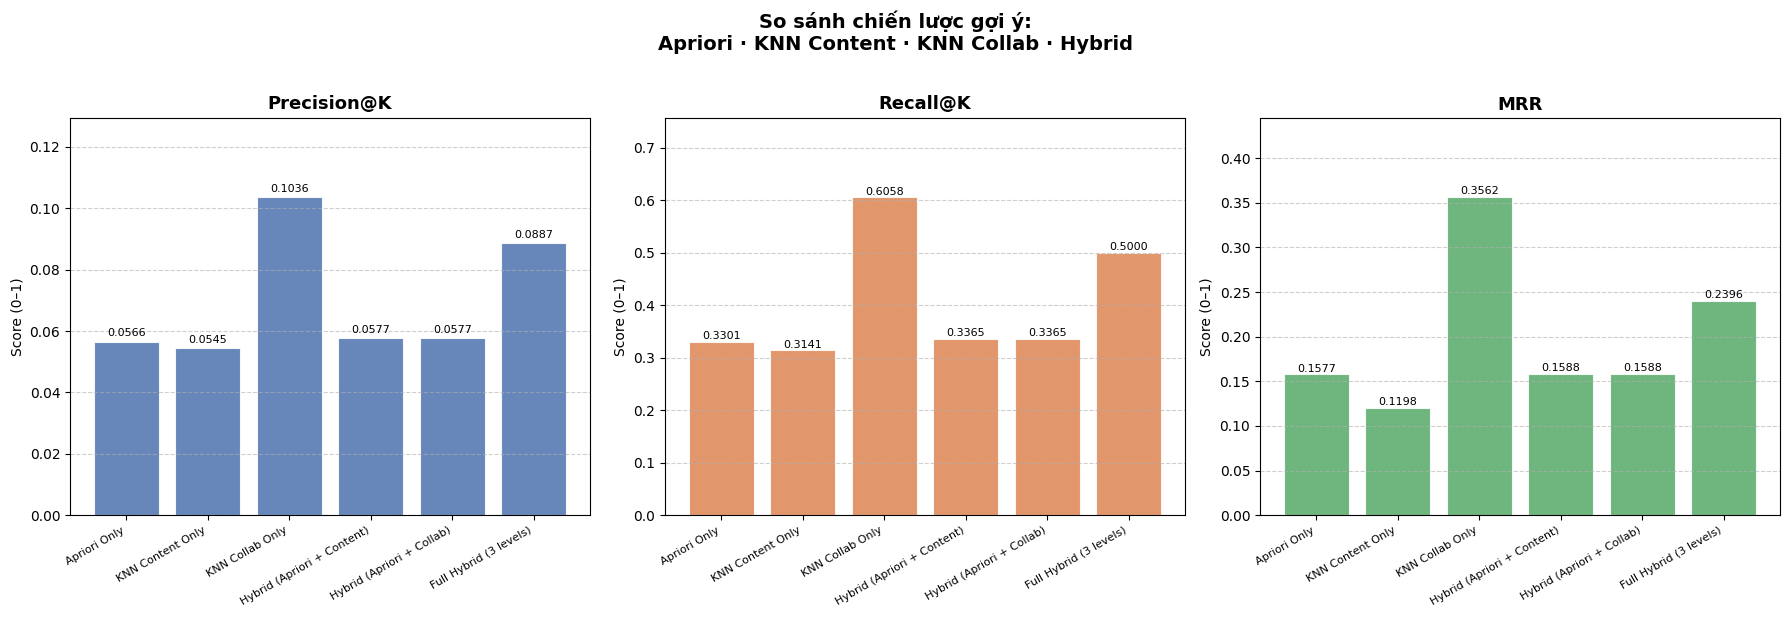


[Done] Biểu đồ đã lưu: recommendation_comparison.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['Precision@K', 'Recall@K', 'MRR']
colors  = ['#4C72B0', '#DD8452', '#55A868']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.bar(
        comparison_df['Strategy'],
        comparison_df[metric],
        color=color, alpha=0.85, edgecolor='white', linewidth=0.8
    )
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score (0–1)', fontsize=10)
    ax.set_ylim(0, max(comparison_df[metric].max() * 1.25, 0.05))
    ax.set_xticks(range(len(comparison_df)))
    ax.set_xticklabels(comparison_df['Strategy'], rotation=30, ha='right', fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    for bar, val in zip(bars, comparison_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(
    'So sánh chiến lược gợi ý:\nApriori · KNN Content · KNN Collab · Hybrid',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('recommendation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[Done] Biểu đồ đã lưu: recommendation_comparison.png")

# ============================================================
# 8. GRID SEARCH – Tìm tối ưu hóa tham số
# ============================================================
# Sử dụng Grid Search để tìm các tham số tốt nhất cho:
#   - Apriori: min_support, min_confidence, max_length
#   - KNN: n_neighbors
# Đánh giá dựa trên Precision@K, Recall@K, MRR

In [11]:
import itertools
from tqdm import tqdm

def grid_search_apriori(transactions, test_trans, product_features, k=6):
    """
    Grid Search cho tham số Apriori.
    Tham số được tối ưu: min_support, min_confidence, max_length
    """
    print("\n" + "=" * 70)
    print("GRID SEARCH – APRIORI")
    print("=" * 70)
    
    # Định nghĩa không gian tham số
    param_grid = {
        'min_support': [0.0001, 0.0002, 0.0005, 0.001],
        'min_confidence': [0.05, 0.1, 0.15, 0.2],
        'max_length': [2, 3, 4]
    }
    
    param_combinations = list(itertools.product(
        param_grid['min_support'],
        param_grid['min_confidence'],
        param_grid['max_length']
    ))
    
    print(f"Số tổ hợp tham số cần kiểm tra: {len(param_combinations)}")
    
    best_score = -1
    best_params = None
    results = []
    
    id_to_cat = dict(zip(
        product_features['product_id'],
        product_features['product_category_name_english']
    ))
    
    for min_sup, min_conf, max_len in tqdm(param_combinations, desc="Grid Search Apriori"):
        try:
            # Tạo model với tham số hiện tại
            itemsets, rules = apriori(
                transactions,
                min_support=min_sup,
                min_confidence=min_conf,
                max_length=max_len
            )
            
            apriori_temp = {}
            for rule in rules:
                lhs_items = list(rule.lhs)
                rhs_items = list(rule.rhs)
                if not lhs_items or not rhs_items:
                    continue
                for lhs_cat in lhs_items:
                    for rhs_cat in rhs_items:
                        apriori_temp.setdefault(lhs_cat, []).append({
                            'category': rhs_cat,
                            'score': round(rule.lift, 4),
                            'method': 'Apriori'
                        })
            
            for cat in apriori_temp:
                apriori_temp[cat] = sorted(apriori_temp[cat],
                                          key=lambda x: x['score'], reverse=True)
            
            # Đánh giá trên test set
            precisions, recalls, rr_scores = [], [], []
            
            for transaction in test_trans:
                if len(transaction) < 2:
                    continue
                
                current_cat = transaction[0]
                actual_cats_set = set(transaction[1:])
                recommendations = []
                
                for cr in apriori_temp.get(current_cat, []):
                    for p in category_to_products.get(cr['category'], [])[:2]:
                        recommendations.append(p)
                    if len(recommendations) >= k:
                        break
                
                recommendations = recommendations[:k]
                pred_cats = [id_to_cat[p] for p in recommendations if p in id_to_cat]
                
                p, r, rr = _compute_metrics(pred_cats, actual_cats_set, k)
                precisions.append(p)
                recalls.append(r)
                rr_scores.append(rr)
            
            avg_precision = np.mean(precisions) if precisions else 0
            avg_recall = np.mean(recalls) if recalls else 0
            avg_mrr = np.mean(rr_scores) if rr_scores else 0
            
            # Tính score tổng hợp (weighted average)
            combined_score = avg_precision * 0.4 + avg_recall * 0.4 + avg_mrr * 0.2
            
            results.append({
                'min_support': min_sup,
                'min_confidence': min_conf,
                'max_length': max_len,
                'Precision@K': round(avg_precision, 4),
                'Recall@K': round(avg_recall, 4),
                'MRR': round(avg_mrr, 4),
                'Combined_Score': round(combined_score, 4)
            })
            
            if combined_score > best_score:
                best_score = combined_score
                best_params = {
                    'min_support': min_sup,
                    'min_confidence': min_conf,
                    'max_length': max_len
                }
        
        except Exception as e:
            continue
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Combined_Score', ascending=False)
    
    print(f"\n[APRIORI] Best Parameters:")
    print(f"  min_support={best_params['min_support']}")
    print(f"  min_confidence={best_params['min_confidence']}")
    print(f"  max_length={best_params['max_length']}")
    print(f"  Combined Score: {best_score:.4f}\n")
    print("Top 10 Parameter Combinations:")
    print(results_df.head(10).to_string(index=False))
    
    return best_params, results_df


# Tách train/test được sử dụng ở phần đánh giá trước
train_trans_grid, test_trans_grid = train_test_split(
    transactions, test_size=0.2, random_state=42
)

best_apriori_params, apriori_grid_results = grid_search_apriori(
    train_trans_grid, test_trans_grid, product_features, k=6
)


GRID SEARCH – APRIORI
Số tổ hợp tham số cần kiểm tra: 48


Grid Search Apriori:   0%|          | 0/48 [00:00<?, ?it/s]

Grid Search Apriori: 100%|██████████| 48/48 [00:00<00:00, 85.23it/s] 


[APRIORI] Best Parameters:
  min_support=0.0001
  min_confidence=0.1
  max_length=2
  Combined Score: 0.2319

Top 10 Parameter Combinations:
 min_support  min_confidence  max_length  Precision@K  Recall@K    MRR  Combined_Score
      0.0001            0.10           2       0.0652    0.3814 0.2662          0.2319
      0.0002            0.10           2       0.0652    0.3814 0.2662          0.2319
      0.0010            0.10           2       0.0652    0.3814 0.2662          0.2319
      0.0005            0.10           2       0.0652    0.3814 0.2662          0.2319
      0.0005            0.05           2       0.0641    0.3750 0.1667          0.2090
      0.0010            0.05           2       0.0641    0.3750 0.1667          0.2090
      0.0002            0.05           2       0.0641    0.3750 0.1667          0.2090
      0.0001            0.05           2       0.0641    0.3750 0.1667          0.2090
      0.0002            0.10           4       0.0566    0.3301 0.1577     

In [12]:
def grid_search_knn(transactions, test_trans, product_features, k=6):
    """
    Grid Search cho tham số KNN (Content-Based và Collaborative).
    Tham số được tối ưu: n_neighbors (cho cả 2 loại KNN)
    """
    print("\n" + "=" * 70)
    print("GRID SEARCH – KNN PARAMETERS")
    print("=" * 70)
    
    # Định nghĩa không gian tham số
    knn_neighbors = [5, 10, 15, 20, 30, 40, 50]
    
    print(f"Số tổ hợp tham số cần kiểm tra: {len(knn_neighbors)}")
    
    best_score = -1
    best_params = None
    results = []
    
    id_to_cat = dict(zip(
        product_features['product_id'],
        product_features['product_category_name_english']
    ))
    
    for n_neighbors in tqdm(knn_neighbors, desc="Grid Search KNN"):
        try:
            # Huấn luyện KNN Content-Based với tham số mới
            numerical_features = ['product_weight_g', 'product_length_cm',
                                 'product_height_cm', 'product_width_cm']
            pf = product_features.reset_index(drop=True)
            scaler = StandardScaler()
            feature_matrix_temp = scaler.fit_transform(pf[numerical_features].values)
            
            knn_content_temp = NearestNeighbors(
                n_neighbors=min(n_neighbors, len(feature_matrix_temp)-1),
                metric='cosine', algorithm='brute'
            )
            knn_content_temp.fit(feature_matrix_temp)
            
            # Huấn luyện KNN Collaborative với tham số mới
            cat_customer_matrix_temp = customer_cat_matrix.T
            knn_collab_temp = NearestNeighbors(
                n_neighbors=min(n_neighbors, len(cat_customer_matrix_temp)-1),
                metric='cosine', algorithm='brute'
            )
            knn_collab_temp.fit(cat_customer_matrix_temp.values)
            
            # Đánh giá hybrid model với KNN parameters mới
            precisions, recalls, rr_scores = [], [], []
            
            for transaction in test_trans:
                if len(transaction) < 2:
                    continue
                
                current_cat = transaction[0]
                actual_cats_set = set(transaction[1:])
                recommendations = []
                
                # Lấy sản phẩm đại diện cho danh mục hiện tại
                sample_p_id = category_to_products.get(current_cat, [None])[0]
                
                if sample_p_id:
                    # Sử dụng hybrid approach với KNN parameters mới
                    seen_ids = {sample_p_id}
                    
                    # Tầng 1: Apriori (giữ nguyên)
                    suggested_cats = apriori_rules_lookup.get(current_cat, [])
                    for cr in suggested_cats[:3]:
                        for p in category_to_products.get(cr['category'], [])[:2]:
                            if p not in seen_ids:
                                recommendations.append(p)
                                seen_ids.add(p)
                        if len(recommendations) >= k:
                            break
                    
                    # Tầng 2: KNN Collaborative (với n_neighbors mới)
                    if len(recommendations) < k:
                        try:
                            category_names_temp = list(cat_customer_matrix_temp.index)
                            if current_cat in category_names_temp:
                                cat_idx = category_names_temp.index(current_cat)
                                distances, indices = knn_collab_temp.kneighbors(
                                    [cat_customer_matrix_temp.iloc[cat_idx].values],
                                    n_neighbors=min(n_neighbors, len(category_names_temp)-1)
                                )
                                for i in range(1, len(indices[0])):
                                    neighbor_cat = category_names_temp[indices[0][i]]
                                    for p in category_to_products.get(neighbor_cat, []):
                                        if p not in seen_ids:
                                            recommendations.append(p)
                                            seen_ids.add(p)
                                            break
                                    if len(recommendations) >= k:
                                        break
                        except Exception:
                            pass
                    
                    # Tầng 3: KNN Content-Based (với n_neighbors mới)
                    if len(recommendations) < k:
                        try:
                            pos_idx = pf[pf['product_id'] == sample_p_id].index[0]
                            distances, indices = knn_content_temp.kneighbors(
                                feature_matrix_temp[pos_idx].reshape(1, -1),
                                n_neighbors=min(n_neighbors + 10, len(feature_matrix_temp)-1)
                            )
                            for i in range(1, len(indices[0])):
                                neighbor_id = pf.iloc[indices[0][i]]['product_id']
                                neighbor_cat = pf.iloc[indices[0][i]]['product_category_name_english']
                                if neighbor_id not in seen_ids and neighbor_cat != current_cat:
                                    recommendations.append(neighbor_id)
                                    seen_ids.add(neighbor_id)
                                if len(recommendations) >= k:
                                    break
                        except Exception:
                            pass
                
                recommendations = recommendations[:k]
                pred_cats = [id_to_cat[p] for p in recommendations if p in id_to_cat]
                
                p, r, rr = _compute_metrics(pred_cats, actual_cats_set, k)
                precisions.append(p)
                recalls.append(r)
                rr_scores.append(rr)
            
            avg_precision = np.mean(precisions) if precisions else 0
            avg_recall = np.mean(recalls) if recalls else 0
            avg_mrr = np.mean(rr_scores) if rr_scores else 0
            
            # Tính score tổng hợp
            combined_score = avg_precision * 0.4 + avg_recall * 0.4 + avg_mrr * 0.2
            
            results.append({
                'n_neighbors': n_neighbors,
                'Precision@K': round(avg_precision, 4),
                'Recall@K': round(avg_recall, 4),
                'MRR': round(avg_mrr, 4),
                'Combined_Score': round(combined_score, 4)
            })
            
            if combined_score > best_score:
                best_score = combined_score
                best_params = n_neighbors
        
        except Exception as e:
            continue
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Combined_Score', ascending=False)
    
    print(f"\n[KNN] Best Parameter:")
    print(f"  n_neighbors={best_params}")
    print(f"  Combined Score: {best_score:.4f}\n")
    print("All Parameter Results:")
    print(results_df.to_string(index=False))
    
    return best_params, results_df


best_knn_params, knn_grid_results = grid_search_knn(
    train_trans_grid, test_trans_grid, product_features, k=6
)


GRID SEARCH – KNN PARAMETERS
Số tổ hợp tham số cần kiểm tra: 7


Grid Search KNN: 100%|██████████| 7/7 [00:17<00:00,  2.51s/it]


[KNN] Best Parameter:
  n_neighbors=5
  Combined Score: 0.2025

All Parameter Results:
 n_neighbors  Precision@K  Recall@K    MRR  Combined_Score
           5       0.0641    0.3558 0.1726          0.2025
          10       0.0641    0.3558 0.1726          0.2025
          15       0.0641    0.3558 0.1726          0.2025
          20       0.0641    0.3558 0.1726          0.2025
          30       0.0641    0.3558 0.1726          0.2025
          40       0.0641    0.3558 0.1726          0.2025
          50       0.0641    0.3558 0.1726          0.2025


# ============================================================
# 9. VISUALIZATION – Kết quả Grid Search
# ============================================================

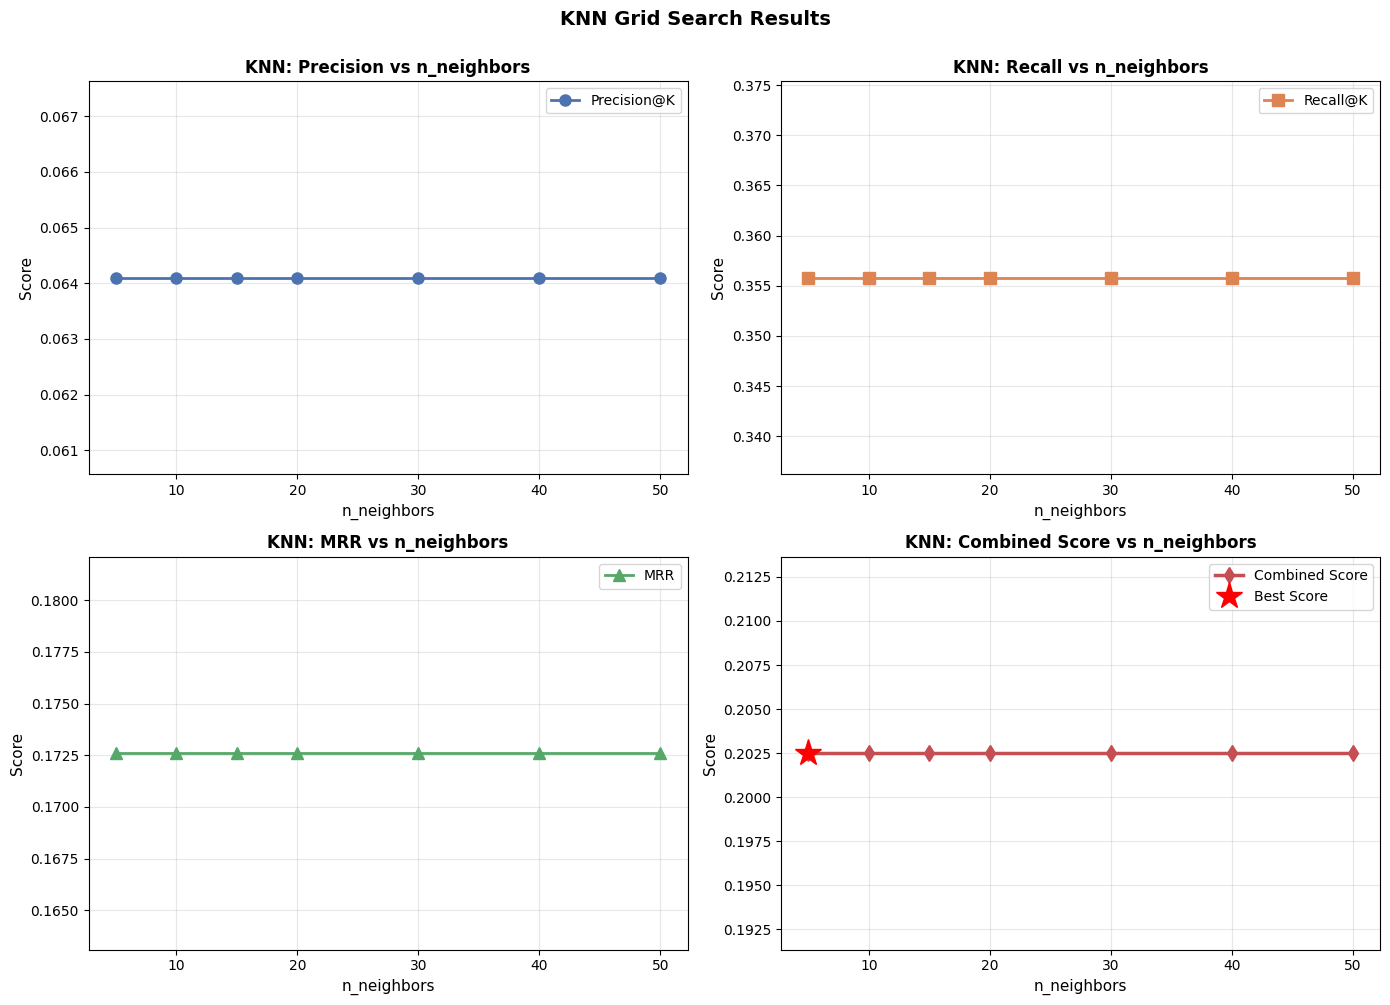

[Done] KNN Grid Search plot saved: knn_grid_search.png


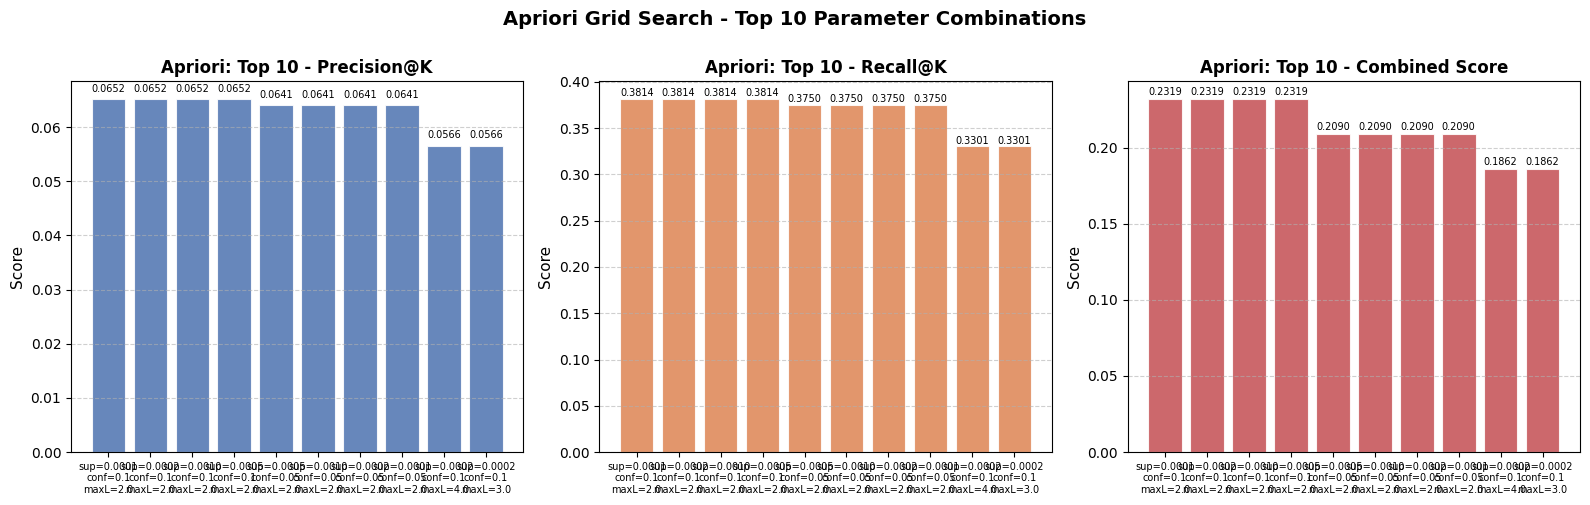

[Done] Apriori Grid Search plot saved: apriori_grid_search.png

GRID SEARCH SUMMARY

[APRIORI] Best Parameters:
  min_support = 0.0001
  min_confidence = 0.1
  max_length = 2
  Precision@K = 0.0652
  Recall@K = 0.3814
  MRR = 0.2662
  Combined Score = 0.2319

[KNN] Best Parameter:
  n_neighbors = 5
  Precision@K = 0.0641
  Recall@K = 0.3558
  MRR = 0.1726
  Combined Score = 0.2025


In [13]:
# Plot KNN Grid Search Results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# KNN Results - Line plots
ax1 = axes[0, 0]
ax1.plot(knn_grid_results['n_neighbors'], knn_grid_results['Precision@K'], 
         marker='o', label='Precision@K', linewidth=2, markersize=8, color='#4C72B0')
ax1.set_xlabel('n_neighbors', fontsize=11)
ax1.set_ylabel('Score', fontsize=11)
ax1.set_title('KNN: Precision vs n_neighbors', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2 = axes[0, 1]
ax2.plot(knn_grid_results['n_neighbors'], knn_grid_results['Recall@K'], 
         marker='s', label='Recall@K', linewidth=2, markersize=8, color='#DD8452')
ax2.set_xlabel('n_neighbors', fontsize=11)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('KNN: Recall vs n_neighbors', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

ax3 = axes[1, 0]
ax3.plot(knn_grid_results['n_neighbors'], knn_grid_results['MRR'], 
         marker='^', label='MRR', linewidth=2, markersize=8, color='#55A868')
ax3.set_xlabel('n_neighbors', fontsize=11)
ax3.set_ylabel('Score', fontsize=11)
ax3.set_title('KNN: MRR vs n_neighbors', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend()

ax4 = axes[1, 1]
ax4.plot(knn_grid_results['n_neighbors'], knn_grid_results['Combined_Score'], 
         marker='d', label='Combined Score', linewidth=2.5, markersize=8, color='#C44E52')
best_idx = knn_grid_results['Combined_Score'].idxmax()
ax4.plot(knn_grid_results.loc[best_idx, 'n_neighbors'], 
         knn_grid_results.loc[best_idx, 'Combined_Score'],
         'r*', markersize=20, label='Best Score')
ax4.set_xlabel('n_neighbors', fontsize=11)
ax4.set_ylabel('Score', fontsize=11)
ax4.set_title('KNN: Combined Score vs n_neighbors', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.suptitle('KNN Grid Search Results', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('knn_grid_search.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Done] KNN Grid Search plot saved: knn_grid_search.png")

# Plot Apriori Grid Search Results - Top 10 combinations
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

top_10 = apriori_grid_results.head(10)
x_pos = np.arange(len(top_10))
param_labels = [f"sup={row['min_support']:.4f}\nconf={row['min_confidence']}\nmaxL={row['max_length']}" 
                for _, row in top_10.iterrows()]

ax1 = axes[0]
bars1 = ax1.bar(x_pos, top_10['Precision@K'], color='#4C72B0', alpha=0.85, edgecolor='white', linewidth=0.8)
ax1.set_ylabel('Score', fontsize=11)
ax1.set_title('Apriori: Top 10 - Precision@K', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(param_labels, fontsize=7)
ax1.grid(axis='y', linestyle='--', alpha=0.6)
for bar, val in zip(bars1, top_10['Precision@K']):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=7)

ax2 = axes[1]
bars2 = ax2.bar(x_pos, top_10['Recall@K'], color='#DD8452', alpha=0.85, edgecolor='white', linewidth=0.8)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Apriori: Top 10 - Recall@K', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(param_labels, fontsize=7)
ax2.grid(axis='y', linestyle='--', alpha=0.6)
for bar, val in zip(bars2, top_10['Recall@K']):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=7)

ax3 = axes[2]
bars3 = ax3.bar(x_pos, top_10['Combined_Score'], color='#C44E52', alpha=0.85, edgecolor='white', linewidth=0.8)
ax3.set_ylabel('Score', fontsize=11)
ax3.set_title('Apriori: Top 10 - Combined Score', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(param_labels, fontsize=7)
ax3.grid(axis='y', linestyle='--', alpha=0.6)
for bar, val in zip(bars3, top_10['Combined_Score']):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Apriori Grid Search - Top 10 Parameter Combinations', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('apriori_grid_search.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Done] Apriori Grid Search plot saved: apriori_grid_search.png")

# Summary comparison
print("\n" + "=" * 70)
print("GRID SEARCH SUMMARY")
print("=" * 70)
print(f"\n[APRIORI] Best Parameters:")
print(f"  min_support = {best_apriori_params['min_support']}")
print(f"  min_confidence = {best_apriori_params['min_confidence']}")
print(f"  max_length = {best_apriori_params['max_length']}")
best_apriori_score = apriori_grid_results.iloc[0]
print(f"  Precision@K = {best_apriori_score['Precision@K']:.4f}")
print(f"  Recall@K = {best_apriori_score['Recall@K']:.4f}")
print(f"  MRR = {best_apriori_score['MRR']:.4f}")
print(f"  Combined Score = {best_apriori_score['Combined_Score']:.4f}")

print(f"\n[KNN] Best Parameter:")
print(f"  n_neighbors = {best_knn_params}")
best_knn_score = knn_grid_results[knn_grid_results['n_neighbors'] == best_knn_params].iloc[0]
print(f"  Precision@K = {best_knn_score['Precision@K']:.4f}")
print(f"  Recall@K = {best_knn_score['Recall@K']:.4f}")
print(f"  MRR = {best_knn_score['MRR']:.4f}")
print(f"  Combined Score = {best_knn_score['Combined_Score']:.4f}")

# ============================================================
# 10. APPLY OPTIMAL PARAMETERS – Huấn luyện mô hình cuối cùng
# ============================================================
# Sử dụng các tham số tối ưu từ grid search để huấn luyện mô hình chính thức

In [14]:
# Huấn luyện Apriori với tham số tối ưu
print("\n" + "=" * 70)
print("TRAINING OPTIMIZED MODELS")
print("=" * 70)

itemsets_optimized, rules_optimized = apriori(
    transactions,
    min_support=best_apriori_params['min_support'],
    min_confidence=best_apriori_params['min_confidence'],
    max_length=best_apriori_params['max_length']
)

apriori_optimized = {}
for rule in rules_optimized:
    lhs_items = list(rule.lhs)
    rhs_items = list(rule.rhs)
    if not lhs_items or not rhs_items:
        continue
    for lhs_cat in lhs_items:
        for rhs_cat in rhs_items:
            apriori_optimized.setdefault(lhs_cat, []).append({
                'category': rhs_cat,
                'score': round(rule.lift, 4),
                'method': 'Apriori'
            })

for cat in apriori_optimized:
    apriori_optimized[cat] = sorted(apriori_optimized[cat],
                                   key=lambda x: x['score'], reverse=True)

print(f"\n[APRIORI OPTIMIZED]")
print(f"  Number of rules: {len(rules_optimized)}")
print(f"  Parameters: min_support={best_apriori_params['min_support']}, "
      f"min_confidence={best_apriori_params['min_confidence']}, "
      f"max_length={best_apriori_params['max_length']}")

# Huấn luyện KNN với tham số tối ưu
print(f"\n[KNN OPTIMIZED]")
print(f"  n_neighbors: {best_knn_params}")

# Hàm gợi ý cuối cùng sử dụng tham số tối ưu
def get_hybrid_recommendations_optimized(product_id, k=10, apriori_model=None, 
                                         knn_neighbors_param=None):
    """
    Hàm gợi ý hybrid sử dụng tham số tối ưu từ grid search.
    """
    if apriori_model is None:
        apriori_model = apriori_optimized
    if knn_neighbors_param is None:
        knn_neighbors_param = best_knn_params
    
    final_recs = []
    seen_ids = {product_id}
    
    rows = product_features[product_features['product_id'] == product_id]
    if rows.empty:
        return []
    current_cat = rows.iloc[0]['product_category_name_english']
    
    # Tầng 1: Apriori
    suggested_cats = apriori_model.get(current_cat, [])
    unique_suggested_cats = []
    seen_cat = set()
    for cat_rule in suggested_cats:
        if cat_rule['category'] not in seen_cat:
            unique_suggested_cats.append(cat_rule)
            seen_cat.add(cat_rule['category'])
    suggested_cats = unique_suggested_cats
    
    apriori_cat_counts = {cat_rule['category']: 0 for cat_rule in suggested_cats}
    max_per_category = 1
    
    while len(final_recs) < k:
        added = False
        for cat_rule in suggested_cats:
            target_cat = cat_rule['category']
            if apriori_cat_counts[target_cat] >= max_per_category:
                continue
            
            for p_id in category_to_products.get(target_cat, []):
                if p_id not in seen_ids:
                    final_recs.append({
                        'product_id': p_id,
                        'score': cat_rule['score'],
                        'method': f"Apriori (combo: {target_cat})"
                    })
                    seen_ids.add(p_id)
                    apriori_cat_counts[target_cat] += 1
                    added = True
                    break
            
            if len(final_recs) >= k:
                break
        
        if not added:
            break
    
    # Tầng 2: KNN Collaborative (với n_neighbors tối ưu)
    if len(final_recs) < k and current_cat in category_names:
        try:
            cat_idx = category_names.index(current_cat)
            distances, indices = knn_collab.kneighbors(
                [cat_customer_matrix.iloc[cat_idx].values], 
                n_neighbors=min(knn_neighbors_param, len(category_names)-1)
            )
            for i in range(1, len(indices[0])):
                neighbor_cat = category_names[indices[0][i]]
                sim_score = round(1 - distances[0][i], 4)
                if sim_score <= 0:
                    continue
                for p_id in category_to_products.get(neighbor_cat, []):
                    if p_id not in seen_ids:
                        final_recs.append({
                            'product_id': p_id,
                            'score': sim_score,
                            'method': f'KNN Collab (behavior sim: {neighbor_cat})'
                        })
                        seen_ids.add(p_id)
                        break
                if len(final_recs) >= k:
                    break
        except Exception as e:
            pass
    
    # Tầng 3: KNN Content-Based (với n_neighbors tối ưu)
    if len(final_recs) < k:
        try:
            pos_idx = product_features[product_features['product_id'] == product_id].index[0]
            distances, indices = knn_content.kneighbors(
                feature_matrix[pos_idx].reshape(1, -1), 
                n_neighbors=min(knn_neighbors_param + 20, len(product_features)-1)
            )
            for i in range(1, len(indices[0])):
                neighbor_id = product_features.iloc[indices[0][i]]['product_id']
                neighbor_cat = product_features.iloc[indices[0][i]]['product_category_name_english']
                sim_score = round(1 - distances[0][i], 4)
                if neighbor_id not in seen_ids and neighbor_cat != current_cat:
                    final_recs.append({
                        'product_id': neighbor_id,
                        'score': sim_score,
                        'method': f'KNN Content (phys sim, cat: {neighbor_cat})'
                    })
                    seen_ids.add(neighbor_id)
                if len(final_recs) >= k:
                    break
        except Exception as e:
            pass
    
    return final_recs[:k]


# Demo với tham số tối ưu
print("\n" + "=" * 70)
print("DEMO – RECOMMENDATIONS WITH OPTIMIZED PARAMETERS")
print("=" * 70)

for i in range(5):
    test_id = product_features['product_id'].iloc[i]
    test_cat = product_features[product_features['product_id'] == test_id]['product_category_name_english'].values[0]
    print("\n" + "-" * 70)
    print(f"Product: {test_id}  |  Category: {test_cat}")
    print("-" * 70)
    
    recommendations = get_hybrid_recommendations_optimized(test_id, k=10)
    for idx, r in enumerate(recommendations, 1):
        print(f"{idx:2d}. [{r['method']}]  ID: {r['product_id']:20s}  |  Score: {r['score']:.4f}")


TRAINING OPTIMIZED MODELS

[APRIORI OPTIMIZED]
  Number of rules: 168
  Parameters: min_support=0.0001, min_confidence=0.1, max_length=2

[KNN OPTIMIZED]
  n_neighbors: 5

DEMO – RECOMMENDATIONS WITH OPTIMIZED PARAMETERS

----------------------------------------------------------------------
Product: 1e9e8ef04dbcff4541ed26657ea517e5  |  Category: perfumery
----------------------------------------------------------------------
 1. [Apriori (combo: health_beauty)]  ID: e3e020af31d4d89d2602272b315c3f6e  |  Score: 4.4757
 2. [Apriori (combo: sports_leisure)]  ID: 96bd76ec8810374ed1b65e291975717f  |  Score: 1.2037
 3. [KNN Collab (behavior sim: health_beauty)]  ID: c5d8079278e912d7e3b6beb48ecb56e8  |  Score: 0.0049
 4. [KNN Collab (behavior sim: furniture_decor)]  ID: 2548af3e6e77a690cf3eb6368e9ab61e  |  Score: 0.0037
 5. [KNN Collab (behavior sim: food)]  ID: 33202a8e7a645388c41ed714203d7131  |  Score: 0.0035
 6. [KNN Collab (behavior sim: sports_leisure)]  ID: 3bb7f144022e6732727d8d838a7